# 04 – Global Sensitivity Analysis

This notebook performs a Sobol sensitivity analysis and rule-induction-based feature scoring
on the "A.5_Expected Number of Deaths" outcome under a `do_nothing` policy.



## 1. Setup and Model Initialization
We
import necessary

libraries, define
the
problem, and set
up
the
model
using
formulation
3.


In [3]:
from ema_workbench import (
    Model, Policy, ema_logging,
    Samplers, MultiprocessingEvaluator
)
from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench.analysis import feature_scoring
from ema_workbench.analysis.scenario_discovery_util import RuleInductionType
from SALib.analyze import sobol

from dike_model_function import DikeNetwork
from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ema_logging.log_to_stderr(ema_logging.INFO)

def setup_model(formulation_index=3):
    model, planning_steps = get_model_for_problem_formulation(formulation_index)
    uncertainties = model.uncertainties.copy()
    problem = get_SALib_problem(uncertainties)
    return model, problem, uncertainties

dike_model, problem, uncertainties = setup_model()


## 2. Define Do-Nothing Policy


In [4]:
def create_do_nothing_policy(model):
    return Policy('do_nothing', **{lever.name: 0 for lever in model.levers})

donothing_policy = create_do_nothing_policy(dike_model)


## 3. Run Sobol Sampling


In [5]:
def run_sobol_experiments(model, policy, n_scenarios=1):
    with MultiprocessingEvaluator(model) as evaluator:
        experiments, outcomes = evaluator.perform_experiments(
            scenarios=n_scenarios,
            policies=policy,
            uncertainty_sampling=Samplers.SOBOL
        )
    return experiments, outcomes

experiments_sobol, outcomes_sobol = run_sobol_experiments(dike_model, donothing_policy)


[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] performing 40 scenarios * 1 policies * 1 model(s) = 40 experiments
100%|██████████████████████████████████████████| 40/40 [00:01<00:00, 35.13it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


## 4. Perform Sobol Sensitivity Analysis


In [6]:
def analyze_sobol(problem, outcome_array):
    return sobol.analyze(problem, outcome_array, calc_second_order=True, print_to_console=True)

a5_deaths = outcomes_sobol['A.5_Expected Number of Deaths']
Si = analyze_sobol(problem, a5_deaths)

def sobol_to_dataframe(Si_dict):
    return pd.DataFrame({
        'S1': Si_dict['S1'],
        'S1_conf': Si_dict['S1_conf'],
        'ST': Si_dict['ST'],
        'ST_conf': Si_dict['ST_conf']
    }, index=problem['names'])

Si_df = sobol_to_dataframe(Si)


                                 ST       ST_conf
A.0_ID flood wave shape    2.000000  0.000000e+00
A.1_Bmax                   0.000000  0.000000e+00
A.1_Brate                  0.000000  0.000000e+00
A.1_pfail                  2.000000  0.000000e+00
A.2_Bmax                   2.000000  0.000000e+00
A.2_Brate                  0.000000  0.000000e+00
A.2_pfail                134.772015  5.598616e-14
A.3_Bmax                   0.000000  0.000000e+00
A.3_Brate                  0.000000  0.000000e+00
A.3_pfail                  0.000000  0.000000e+00
A.4_Bmax                   0.000000  0.000000e+00
A.4_Brate                  0.000000  0.000000e+00
A.4_pfail                  0.000000  0.000000e+00
A.5_Bmax                   0.000000  0.000000e+00
A.5_Brate                  0.000000  0.000000e+00
A.5_pfail                  2.000000  0.000000e+00
discount rate 0            0.000000  0.000000e+00
discount rate 1            0.000000  0.000000e+00
discount rate 2            0.000000  0.000000e+00


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


## 5. Plot Sobol Indices (Bar Plot with Error Bars)


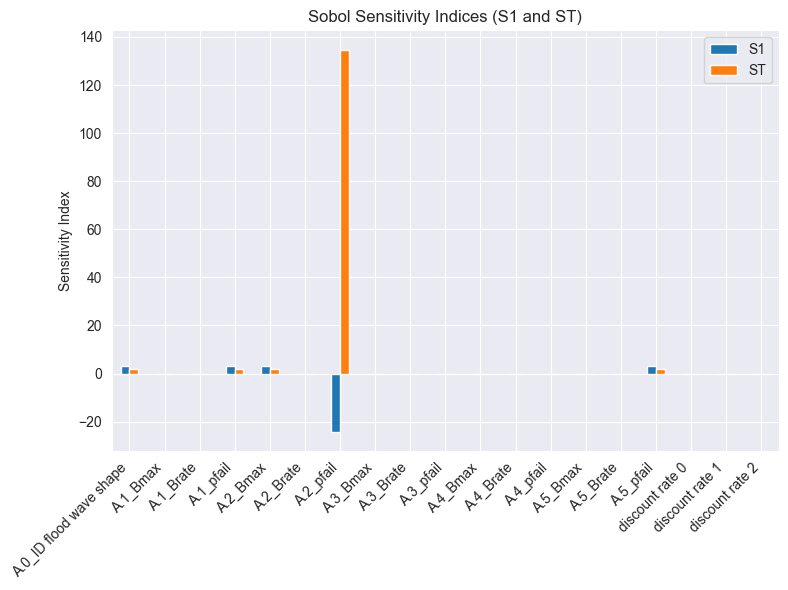

In [7]:
def plot_sobol_bars(Si_df):
    fig, ax = plt.subplots()
    indices = Si_df[['S1', 'ST']]
    errors = Si_df[['S1_conf', 'ST_conf']]
    indices.plot.bar(yerr=errors.values.T, ax=ax)
    fig.set_size_inches(8, 6)
    fig.subplots_adjust(bottom=0.3)
    plt.title("Sobol Sensitivity Indices (S1 and ST)")
    plt.ylabel("Sensitivity Index")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_sobol_bars(Si_df)


## 6. Heatmap of Sobol Indices (S1 and ST)


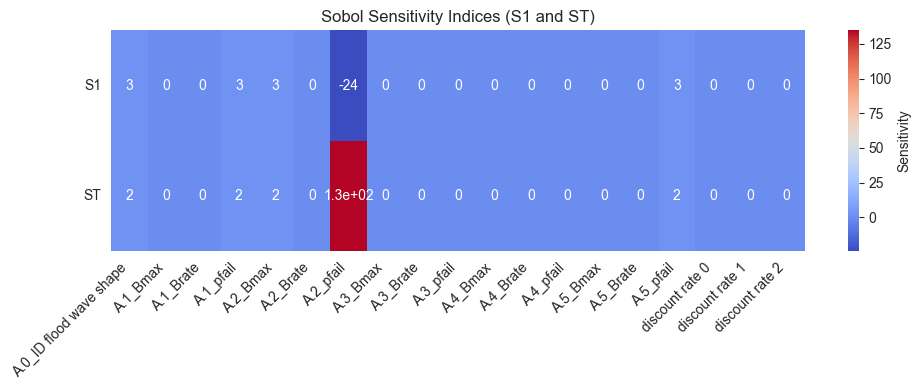

In [8]:
def plot_sobol_heatmap(Si_df):
    heatmap_data = Si_df[['S1', 'ST']].T
    plt.figure(figsize=(10, 4))
    sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', cbar_kws={'label': 'Sensitivity'})
    plt.title('Sobol Sensitivity Indices (S1 and ST)')
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_sobol_heatmap(Si_df)


## 7. Feature Scoring via Rule Induction


In [9]:
def get_feature_scores(experiments, outcome):
    scores = feature_scoring.get_ex_feature_scores(
        experiments,
        outcome,
        max_features=0.6,
        mode=RuleInductionType.REGRESSION
    )[0]
    return scores

initial_scores = get_feature_scores(experiments_sobol, a5_deaths)
print(initial_scores)


                                1
0                                
A.2_pfail                0.415606
A.1_pfail                0.294265
A.2_Bmax                 0.071018
A.5_pfail                0.056511
A.0_ID flood wave shape  0.040697
A.3_Bmax                 0.020583
A.4_Bmax                 0.020308
A.5_Bmax                 0.018074
A.1_Bmax                 0.015245
discount rate 1          0.015189
A.3_pfail                0.012979
A.1_Brate                0.009411
A.4_pfail                0.008786
A.5_Brate                0.001326
0_RfR 0                  0.000000
0_RfR 1                  0.000000
0_RfR 2                  0.000000
1_RfR 0                  0.000000
1_RfR 1                  0.000000
1_RfR 2                  0.000000
2_RfR 0                  0.000000
2_RfR 1                  0.000000
2_RfR 2                  0.000000
3_RfR 0                  0.000000
3_RfR 1                  0.000000
3_RfR 2                  0.000000
4_RfR 0                  0.000000
4_RfR 1       

## 8. Track Feature Importance over Sample Size


In [10]:
def track_feature_scores(experiments, outcome, step=30):
    combined_scores = []
    for j in range(step, experiments.shape[0] + 1, step):
        scores = get_feature_scores(experiments.iloc[:j], outcome[:j])
        scores.columns = [j]
        combined_scores.append(scores)
    return pd.concat(combined_scores, axis=1)

all_scores_df = track_feature_scores(experiments_sobol, a5_deaths)


## 9. Plot Feature Score Heatmap


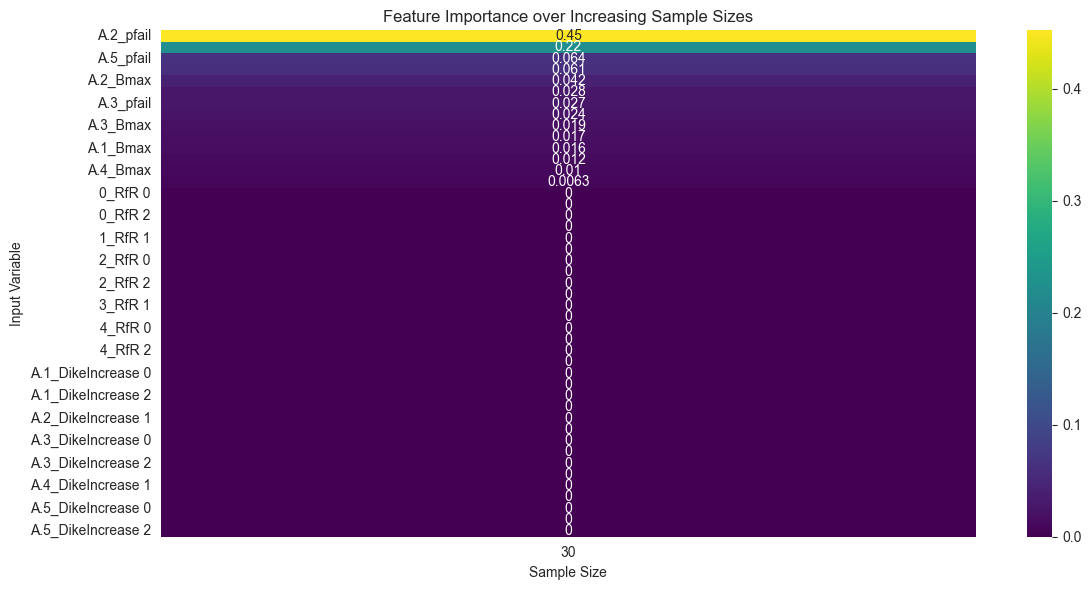

In [11]:
def plot_feature_score_heatmap(scores_df):
    plt.figure(figsize=(12, 6))
    sns.heatmap(scores_df, annot=True, cmap="viridis")
    plt.title('Feature Importance over Increasing Sample Sizes')
    plt.xlabel('Sample Size')
    plt.ylabel('Input Variable')
    plt.tight_layout()
    plt.show()

plot_feature_score_heatmap(all_scores_df)


## 10. Plot Feature Score Trends (Line Chart)


/var/folders/64/05z9tvhd1mn8h92shl8zdmwr0000gn/T/ipykernel_95320/1707489030.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


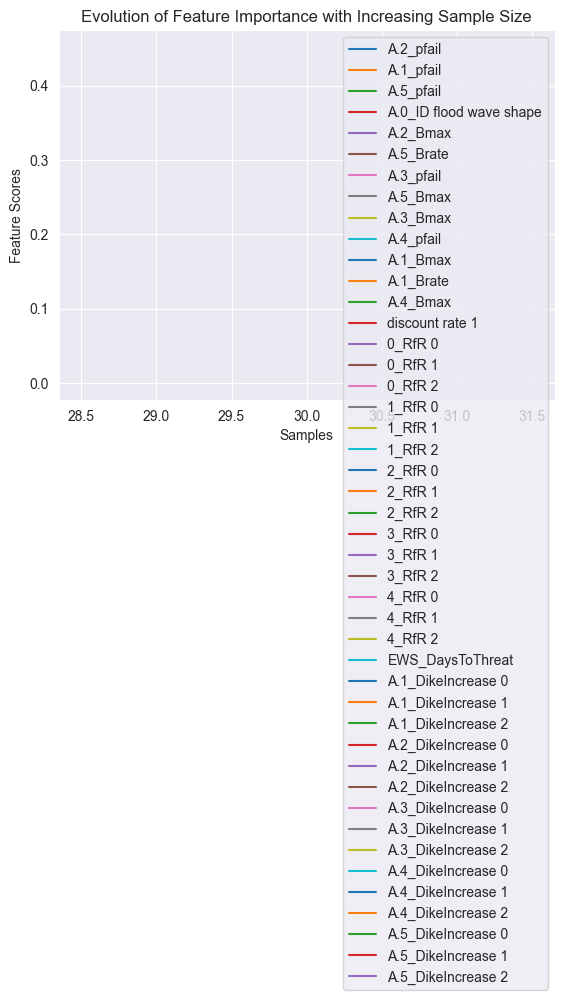

In [12]:
def plot_feature_score_trends(scores_df):
    fig, ax = plt.subplots()
    scores_df.T.plot(ax=ax)
    ax.legend(bbox_to_anchor=(1, 1))
    ax.set_xlabel('Samples')
    ax.set_ylabel('Feature Scores')
    plt.title("Evolution of Feature Importance with Increasing Sample Size")
    plt.tight_layout()
    plt.show()

plot_feature_score_trends(all_scores_df)
